<a href="https://colab.research.google.com/github/olithainduvara/FloodLink_2.0/blob/main/FloodLink_2_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 FloodLink 2.0 — XGBoost Flood Prediction Model
**Step 1: Train XGBoost on Water Level + Rainfall Data**

This notebook:
1. Loads and cleans your Peradeniya hydro station CSV
2. Engineers time-lag features (rolling rainfall, water level history)
3. Trains an XGBoost model to predict future water level
4. Evaluates accuracy and visualizes predictions
5. Saves the trained model for use in FloodLink system


## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Install required libraries (already available in Colab, but just in case)
!pip install xgboost scikit-learn pandas matplotlib seaborn joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 📂 Step 2 — Upload & Load Your CSV
Run the cell below and upload your `Water_Level.csv` file when prompted.

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload your CSV here

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ File loaded: {filename}')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
df.head(10)

Saving Water Level (1) (1).csv to Water Level (1) (1) (1).csv
✅ File loaded: Water Level (1) (1) (1).csv
📊 Shape: 86 rows × 3 columns



,CreationDate,Water Level (m),Rainfall (mm/hr)
0,2026-04-29T09:02:24.798,1.48,1.5203
1,2026-04-29T10:06:34.925,1.42,2.3487
2,2026-04-29T11:05:43.675,1.40,2.4581
3,2026-04-29T12:09:40.718,1.38,3.4274
4,2026-04-29T13:04:20.209,1.35,0.5417
5,2026-04-29T14:08:33.896,1.32,2.0368
6,2026-04-29T15:04:04.759,1.30,1.7954
7,2026-04-29T16:07:52.697,1.30,0.8770
8,2026-04-29T17:05:56.919,1.30,0.0327
9,2026-04-29T18:02:58.312,1.28,0.0181


## 🧹 Step 3 — Clean & Prepare the Data

In [ ]:
# ----- Rename columns for easy use -----
df.columns = ['timestamp', 'water_level', 'rainfall']

# ----- Parse timestamp -----
# format='mixed' handles rows with and without milliseconds in your CSV
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df = df.sort_values('timestamp').reset_index(drop=True)

# ----- Check for missing values -----
print('Missing values:')
print(df.isnull().sum())

# ----- Fill any missing values (forward fill is safe for time series) -----
df = df.ffill()

# ----- Basic stats -----
print('\nDataset Summary:')
print(df.describe().round(3))
print(f'\nDate range: {df.timestamp.min()} → {df.timestamp.max()}')

Missing values:
timestamp      0
water_level    0
rainfall       0
dtype: int64

Dataset Summary:
                           timestamp  water_level  rainfall
count                             86       86.000    86.000
mean   2026-05-01 03:59:19.026162688        1.351     0.247
min       2026-04-29 09:02:24.798000        1.150     0.000
25%    2026-04-30 06:17:00.208999936        1.230     0.000
50%    2026-05-01 03:33:20.648499968        1.295     0.000
75%    2026-05-02 01:46:24.554999808        1.415     0.000
max       2026-05-02 23:46:15.952000        1.920     3.427
std                              NaN        0.173     0.706

Date range: 2026-04-29 09:02:24.798000 → 2026-05-02 23:46:15.952000


## 📊 Step 4 — Visualize Raw Data

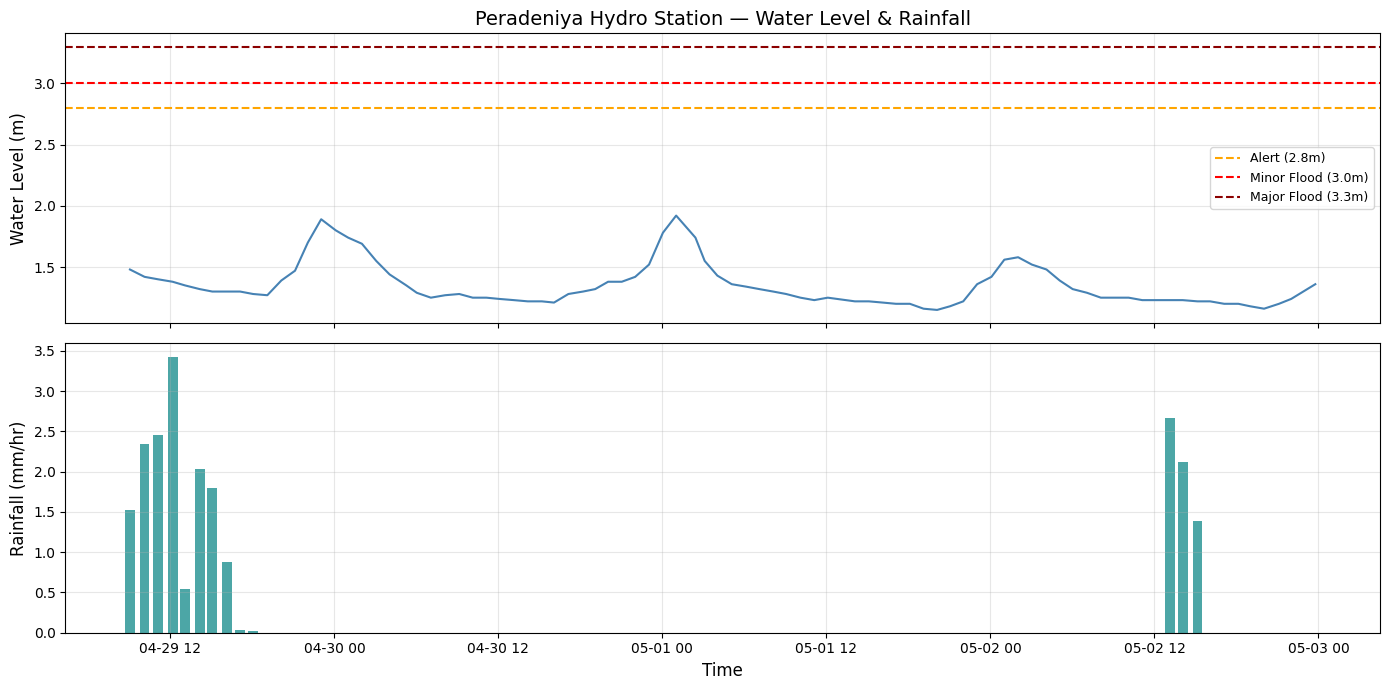

✅ Plot saved as raw_data_plot.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Water Level plot
axes[0].plot(df['timestamp'], df['water_level'], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Water Level (m)', fontsize=12)
axes[0].set_title('Peradeniya Hydro Station — Water Level & Rainfall', fontsize=14)
axes[0].grid(alpha=0.3)

# --- FloodLink threshold lines ---
# ⚠️ IMPORTANT: Change these values to your actual river thresholds!
ALERT_LEVEL   = 2.8   # meters — change to your actual Alert threshold
MINOR_FLOOD   = 3.0   # meters — change to your actual Minor Flood threshold
MAJOR_FLOOD   = 3.3   # meters — change to your actual Major Flood threshold

axes[0].axhline(ALERT_LEVEL,  color='orange', linestyle='--', label=f'Alert ({ALERT_LEVEL}m)')
axes[0].axhline(MINOR_FLOOD,  color='red',    linestyle='--', label=f'Minor Flood ({MINOR_FLOOD}m)')
axes[0].axhline(MAJOR_FLOOD,  color='darkred',linestyle='--', label=f'Major Flood ({MAJOR_FLOOD}m)')
axes[0].legend(fontsize=9)

# Rainfall plot
axes[1].bar(df['timestamp'], df['rainfall'], color='teal', alpha=0.7, width=0.03)
axes[1].set_ylabel('Rainfall (mm/hr)', fontsize=12)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('raw_data_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as raw_data_plot.png')

## ⚙️ Step 5 — Feature Engineering

XGBoost needs hand-crafted time features. We create:
- **Lag features**: water level and rainfall from 1, 2, 3, 6 steps ago
- **Rolling averages**: smoothed trend over past 3 and 6 readings
- **Rate of change**: how fast the water is rising/falling
- **Time features**: hour of day, which helps capture day/night patterns

In [ ]:
# ----- How many steps ahead do you want to predict? -----
# Each reading is ~1 hour apart, so PREDICT_STEPS=2 means predicting 2 hours ahead
PREDICT_STEPS = 2   # ← Change this if you want 1h, 3h, etc.

feat = df.copy()

# --- Lag features: past water levels ---
for lag in [1, 2, 3, 6]:
    feat[f'wl_lag_{lag}'] = feat['water_level'].shift(lag)

# --- Lag features: past rainfall ---
for lag in [1, 2, 3, 6]:
    feat[f'rf_lag_{lag}'] = feat['rainfall'].shift(lag)

# --- Rolling mean of water level (trend) ---
feat['wl_roll_mean_3'] = feat['water_level'].rolling(3).mean()
feat['wl_roll_mean_6'] = feat['water_level'].rolling(6).mean()

# --- Rolling sum of rainfall (accumulated rain) ---
feat['rf_roll_sum_3']  = feat['rainfall'].rolling(3).sum()
feat['rf_roll_sum_6']  = feat['rainfall'].rolling(6).sum()

# --- Rate of change (rising or falling?) ---
feat['wl_diff_1'] = feat['water_level'].diff(1)   # change from last reading
feat['wl_diff_2'] = feat['water_level'].diff(2)   # change over last 2 readings

# --- Time-based features ---
feat['hour']       = feat['timestamp'].dt.hour
feat['hour_sin']   = np.sin(2 * np.pi * feat['hour'] / 24)  # cyclical encoding
feat['hour_cos']   = np.cos(2 * np.pi * feat['hour'] / 24)

# --- Target: water level N steps in the future ---
feat['target'] = feat['water_level'].shift(-PREDICT_STEPS)

# --- Drop rows with NaN (from lag/shift operations) ---
feat = feat.dropna().reset_index(drop=True)

print(f'✅ Feature engineering done!')
print(f'📊 Dataset size after feature engineering: {feat.shape[0]} rows')
print(f'🎯 Predicting water level {PREDICT_STEPS} hour(s) ahead')
print(f'\nFeatures created:')
feature_cols = [c for c in feat.columns if c not in ['timestamp','water_level','rainfall','target']]
print(feature_cols)

✅ Feature engineering done!
📊 Dataset size after feature engineering: 78 rows
🎯 Predicting water level 2 hour(s) ahead

Features created:
['wl_lag_1', 'wl_lag_2', 'wl_lag_3', 'wl_lag_6', 'rf_lag_1', 'rf_lag_2', 'rf_lag_3', 'rf_lag_6', 'wl_roll_mean_3', 'wl_roll_mean_6', 'rf_roll_sum_3', 'rf_roll_sum_6', 'wl_diff_1', 'wl_diff_2', 'hour', 'hour_sin', 'hour_cos']


## 🤖 Step 6 — Train the XGBoost Model

In [ ]:
# ----- Define features (X) and target (y) -----
X = feat[feature_cols]
y = feat['target']

# ----- Train/Test split (80% train, 20% test) -----
# IMPORTANT: We use shuffle=False to respect time order!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

# ----- Define XGBoost model -----
model = XGBRegressor(
    n_estimators    = 300,      # number of trees
    max_depth       = 4,        # tree depth (keep low to avoid overfitting on small data)
    learning_rate   = 0.05,     # step size — slower = more accurate
    subsample       = 0.8,      # use 80% of rows per tree (reduces overfitting)
    colsample_bytree= 0.8,      # use 80% of features per tree
    min_child_weight= 3,        # minimum data per leaf
    reg_alpha       = 0.1,      # L1 regularization
    reg_lambda      = 1.0,      # L2 regularization
    random_state    = 42,
    verbosity       = 0
)

# ----- Train! -----
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('✅ Model training complete!')

Training samples : 62
Testing  samples : 16
✅ Model training complete!


## 📏 Step 7 — Evaluate Model Accuracy

In [ ]:
# ----- Predictions -----
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# ----- Metrics -----
def print_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'  MAE  (Mean Absolute Error)  : {mae:.4f} m   ← avg prediction error in meters')
    print(f'  RMSE (Root Mean Sq Error)   : {rmse:.4f} m')
    print(f'  R²   (Accuracy Score)       : {r2:.4f}   ← 1.0 = perfect, >0.85 = good')
    print()

print_metrics(y_train, y_pred_train, 'TRAIN SET')
print_metrics(y_test,  y_pred_test,  'TEST SET (unseen data)')

# ----- Interpretation guide -----
r2_test = r2_score(y_test, y_pred_test)
if r2_test >= 0.90:
    print('🟢 Excellent accuracy! Model is performing very well.')
elif r2_test >= 0.75:
    print('🟡 Good accuracy. Consider adding more training data for improvement.')
else:
    print('🔴 Lower accuracy — this is expected with only ~80 rows. Add more historical data!')

--- TRAIN SET ---
  MAE  (Mean Absolute Error)  : 0.0148 m   ← avg prediction error in meters
  RMSE (Root Mean Sq Error)   : 0.0198 m
  R²   (Accuracy Score)       : 0.9890   ← 1.0 = perfect, >0.85 = good

--- TEST SET (unseen data) ---
  MAE  (Mean Absolute Error)  : 0.0298 m   ← avg prediction error in meters
  RMSE (Root Mean Sq Error)   : 0.0421 m
  R²   (Accuracy Score)       : 0.0028   ← 1.0 = perfect, >0.85 = good

🔴 Lower accuracy — this is expected with only ~80 rows. Add more historical data!


## 📈 Step 8 — Visualize Predictions vs Actual

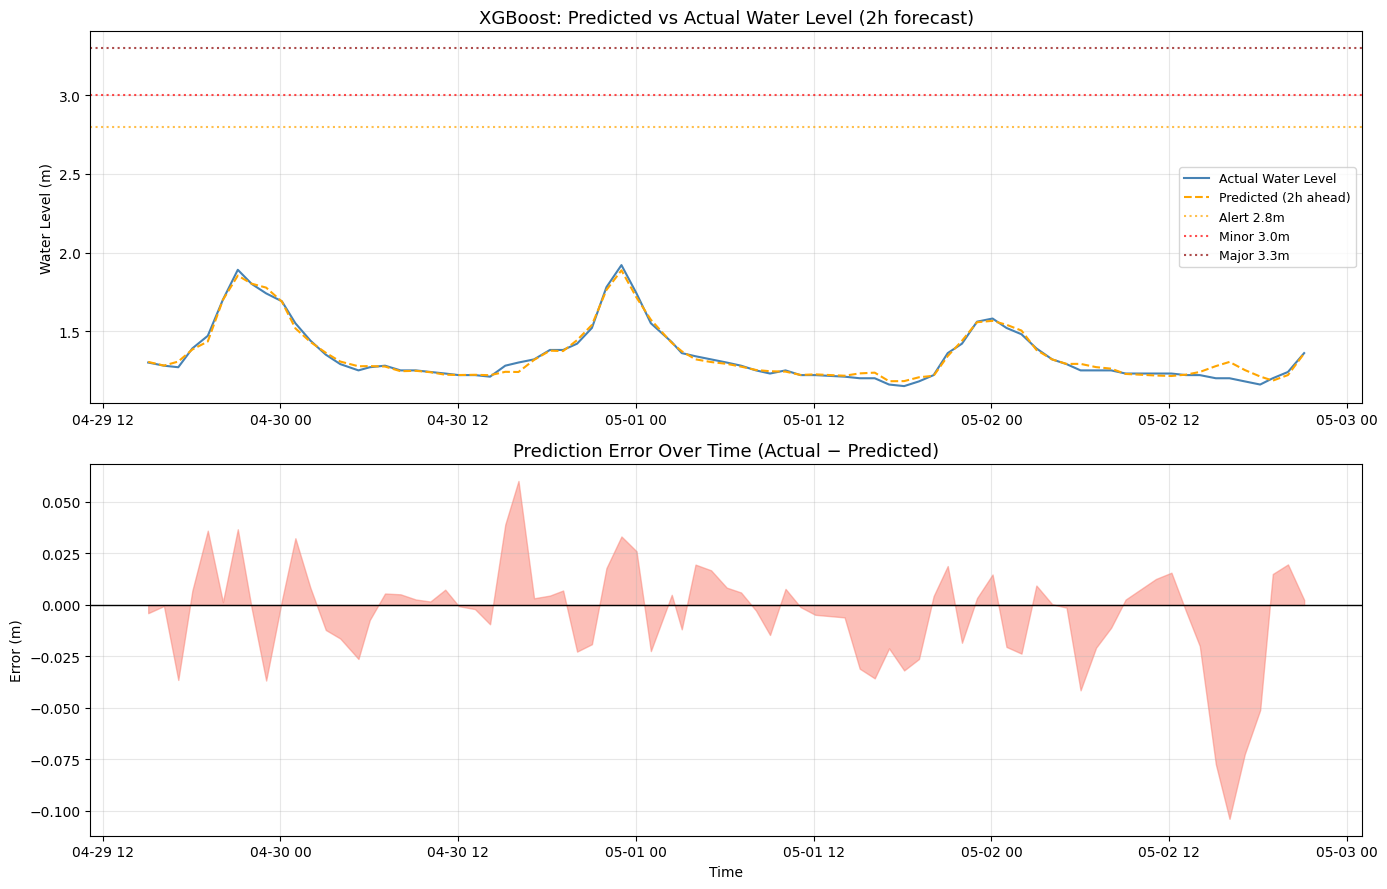

✅ Plot saved as prediction_plot.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ----- Plot 1: Full prediction vs actual -----
all_preds = model.predict(X)
axes[0].plot(feat['timestamp'], y.values,    label='Actual Water Level',    color='steelblue', linewidth=1.5)
axes[0].plot(feat['timestamp'], all_preds,   label=f'Predicted ({PREDICT_STEPS}h ahead)', color='orange',    linewidth=1.5, linestyle='--')
axes[0].axhline(ALERT_LEVEL,  color='orange', linestyle=':', alpha=0.7, label=f'Alert {ALERT_LEVEL}m')
axes[0].axhline(MINOR_FLOOD,  color='red',    linestyle=':', alpha=0.7, label=f'Minor {MINOR_FLOOD}m')
axes[0].axhline(MAJOR_FLOOD,  color='darkred',linestyle=':', alpha=0.7, label=f'Major {MAJOR_FLOOD}m')
axes[0].set_title(f'XGBoost: Predicted vs Actual Water Level ({PREDICT_STEPS}h forecast)', fontsize=13)
axes[0].set_ylabel('Water Level (m)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ----- Plot 2: Error over time -----
errors = y.values - all_preds
axes[1].fill_between(feat['timestamp'], errors, alpha=0.5, color='salmon')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Prediction Error Over Time (Actual − Predicted)', fontsize=13)
axes[1].set_ylabel('Error (m)')
axes[1].set_xlabel('Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as prediction_plot.png')

## 🔍 Step 9 — Feature Importance
Which features matter most to the model?

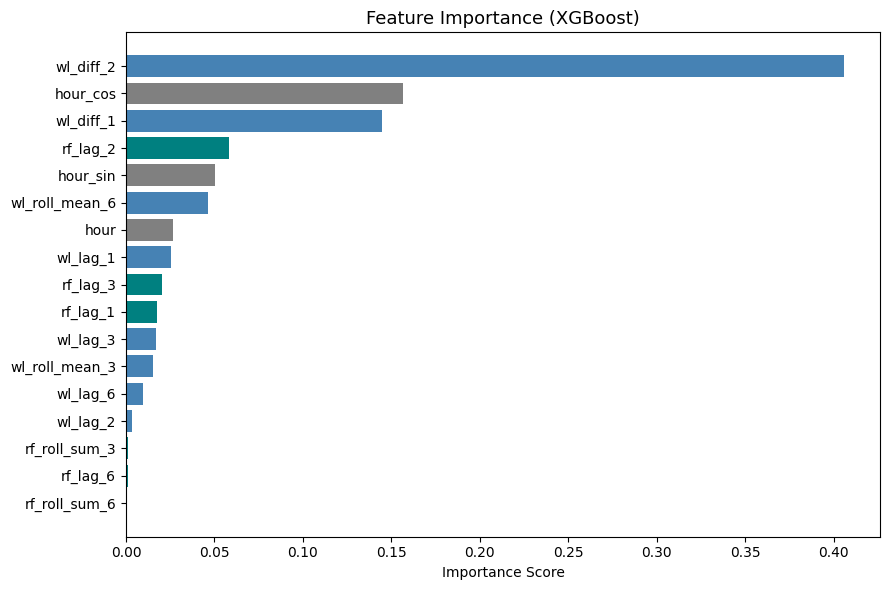


Top 5 most important features:
  Feature  Importance
wl_diff_2    0.405891
 hour_cos    0.156445
wl_diff_1    0.144746
 rf_lag_2    0.058494
 hour_sin    0.050566


In [ ]:
importance = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['steelblue' if 'wl' in f else 'teal' if 'rf' in f else 'gray' for f in importance['Feature']]
plt.barh(importance['Feature'], importance['Importance'], color=colors)
plt.title('Feature Importance (XGBoost)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importance.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 🚨 Step 10 — Flood Alert Prediction Function
This is the function FloodLink will actually call in production.

In [ ]:
def predict_flood_status(recent_df, model, feature_cols, predict_steps=2):
    """
    Given recent sensor readings, predict future water level and flood status.

    Parameters:
        recent_df    : DataFrame with columns [timestamp, water_level, rainfall]
                       Must have at least 7 rows (for lag features to work)
        model        : trained XGBoost model
        feature_cols : list of feature column names
        predict_steps: how many hours ahead to predict

    Returns:
        dict with predicted level and flood status
    """
    # Re-engineer features on the recent window
    tmp = recent_df.copy()
    tmp.columns = ['timestamp', 'water_level', 'rainfall']
    tmp['timestamp'] = pd.to_datetime(tmp['timestamp'])
    tmp = tmp.sort_values('timestamp').reset_index(drop=True)

    for lag in [1, 2, 3, 6]:
        tmp[f'wl_lag_{lag}'] = tmp['water_level'].shift(lag)
        tmp[f'rf_lag_{lag}'] = tmp['rainfall'].shift(lag)

    tmp['wl_roll_mean_3'] = tmp['water_level'].rolling(3).mean()
    tmp['wl_roll_mean_6'] = tmp['water_level'].rolling(6).mean()
    tmp['rf_roll_sum_3']  = tmp['rainfall'].rolling(3).sum()
    tmp['rf_roll_sum_6']  = tmp['rainfall'].rolling(6).sum()
    tmp['wl_diff_1']      = tmp['water_level'].diff(1)
    tmp['wl_diff_2']      = tmp['water_level'].diff(2)
    tmp['hour']           = tmp['timestamp'].dt.hour
    tmp['hour_sin']       = np.sin(2 * np.pi * tmp['hour'] / 24)
    tmp['hour_cos']       = np.cos(2 * np.pi * tmp['hour'] / 24)

    tmp = tmp.dropna()
    if tmp.empty:
        return {'error': 'Not enough data rows (need at least 7)'}

    last_row = tmp[feature_cols].iloc[[-1]]
    predicted_level = float(model.predict(last_row)[0])
    current_level   = float(tmp['water_level'].iloc[-1])

    # --- Determine status ---
    if   predicted_level >= MAJOR_FLOOD:  status = '🔴 MAJOR FLOOD'
    elif predicted_level >= MINOR_FLOOD:  status = '🟠 MINOR FLOOD'
    elif predicted_level >= ALERT_LEVEL:  status = '🟡 ALERT'
    else:                                 status = '🟢 SAFE'

    return {
        'current_level_m'  : round(current_level, 3),
        'predicted_level_m': round(predicted_level, 3),
        'predict_horizon_h': predict_steps,
        'status'           : status
    }


# ----- Test the function with the last 10 rows of your data -----
recent_window = df.tail(20).copy()
result = predict_flood_status(recent_window, model, feature_cols, predict_steps=PREDICT_STEPS)

print('🌊 FloodLink 2.0 — Live Prediction Test')
print('=' * 40)
for k, v in result.items():
    print(f'  {k:<25}: {v}')
print('=' * 40)

🌊 FloodLink 2.0 — Live Prediction Test
  current_level_m          : 1.36
  predicted_level_m        : 1.597
  predict_horizon_h        : 2
  status                   : 🟢 SAFE


## 💾 Step 11 — Save the Trained Model

In [ ]:
# Save model to disk — you can load this in your FloodLink Python system
joblib.dump(model,        'floodlink_xgboost_model.pkl')
joblib.dump(feature_cols, 'floodlink_feature_cols.pkl')

print('✅ Model saved as: floodlink_xgboost_model.pkl')
print('✅ Feature list saved as: floodlink_feature_cols.pkl')
print()
print('To load in your FloodLink system:')
print("  import joblib")
print("  model        = joblib.load('floodlink_xgboost_model.pkl')")
print("  feature_cols = joblib.load('floodlink_feature_cols.pkl')")

# Download files to your computer
files.download('floodlink_xgboost_model.pkl')
files.download('floodlink_feature_cols.pkl')
files.download('raw_data_plot.png')
files.download('prediction_plot.png')
files.download('feature_importance.png')

✅ Model saved as: floodlink_xgboost_model.pkl
✅ Feature list saved as: floodlink_feature_cols.pkl

To load in your FloodLink system:
  import joblib
  model        = joblib.load('floodlink_xgboost_model.pkl')
  feature_cols = joblib.load('floodlink_feature_cols.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ⚠️ Important Notes for FloodLink 2.0

### About Your Current Dataset
Your CSV has **86 rows (~4 days of data)**. XGBoost will train and run, but accuracy will improve significantly as you collect more data. Aim for **at least 3–6 months** of hourly readings.

### Threshold Values to Update
In **Step 4 and Step 10**, update these to your actual Mahaweli/Peradeniya thresholds:
```python
ALERT_LEVEL = 2.8   # your real Alert level in meters
MINOR_FLOOD = 3.0   # your real Minor Flood level
MAJOR_FLOOD = 3.3   # your real Major Flood level
```

### Next Steps for FloodLink 2.0
1. ✅ **Done**: XGBoost baseline model
2. 🔜 **Next**: Collect more data → retrain monthly
3. 🔜 **After**: Upgrade to LSTM for even better time series accuracy
4. 🔜 **After**: Integrate saved model into your Python FloodLink dashboard
